In [1]:
!pip install lightgbm transformers datasets accelerate sentencepiece -q

import pandas as pd
import numpy as np
import re
import ast
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, jaccard_score, hamming_loss
import warnings
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

In [2]:
# =====================================================================================
# FULL MULTI-LABEL PIPELINE (BALANCED + REALISTIC CLEANING + NO LEAKAGE)
# =====================================================================================

import pandas as pd
import numpy as np
import re
import ast
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, jaccard_score, hamming_loss


# =============================================================================
# 1. LOAD DATA
# =============================================================================

df = pd.read_csv("resumes_clean_multilabel(2).csv").fillna("")
print("Loaded columns:", df.columns.tolist())


# =============================================================================
# 2. ENSURE job_labels are lists
# =============================================================================

df["job_labels"] = df["job_labels"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# -------------------------------------------------------------------------
# LABEL COUNTS BEFORE BALANCING
# -------------------------------------------------------------------------
label_counts = df["job_labels"].explode().value_counts()
print("\nOriginal Label Distribution:\n", label_counts)


# =============================================================================
# 3. REMOVE RARE LABELS (<20 samples)
# =============================================================================

min_samples = 20
kept_labels = label_counts[label_counts >= min_samples].index.tolist()
removed_labels = label_counts[label_counts < min_samples].index.tolist()

print("\nLabels removed (<20 samples):", removed_labels)
print("Labels kept:", kept_labels)

# Remove those rare labels from each row
df["job_labels"] = df["job_labels"].apply(
    lambda labels: [lbl for lbl in labels if lbl in kept_labels]
)

# Drop rows with no labels left
df = df[df["job_labels"].apply(len) > 0].reset_index(drop=True)
print("\nShape after removing rare labels:", df.shape)


# =============================================================================
# 4. DOWNSAMPLE SOFTWARE ENGINEER (from 3748 → 1000)
# =============================================================================

major_label = "software engineer"
target_major_samples = 1000

df_major = df[df["job_labels"].apply(lambda x: major_label in x)]
df_other = df[df["job_labels"].apply(lambda x: major_label not in x)]

print("\nSoftware Engineer BEFORE:", len(df_major))

df_major_down = df_major.sample(
    n=min(target_major_samples, len(df_major)),
    random_state=42
)

print("Software Engineer AFTER:", len(df_major_down))

df = pd.concat([df_major_down, df_other]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset shape:", df.shape)
print("\nNew Label Distribution:\n", df["job_labels"].explode().value_counts())


# =============================================================================
# 5. BUILD RAW TEXT (skills + experience + edu + projects)
# =============================================================================

TEXT_COLS = [c for c in ["skills", "experience", "education", "projects"] if c in df.columns]
df["raw_text"] = df[TEXT_COLS].astype(str).agg(" ".join, axis=1).str.lower()


# =============================================================================
# 6. REALISTIC TEXT CLEANING FUNCTIONS
# =============================================================================

# Job-role keywords that leak labels
job_role_keywords = [
    "manager", "management", "project", "operations", "devops",
    "engineer", "developer", "qa", "security", "analyst",
    "cloud", "data", "training", "trainer", "mobile", "sre"
]

def remove_role_indicators(text):
    for kw in job_role_keywords:
        text = re.sub(r"\b" + re.escape(kw) + r"\b", " ", text)
    return text

# Skills that leak roles
skill_leaks = [
    "aws", "devops", "cloud engineer", "data engineer", "python developer",
    "project manager", "software engineer", "qa engineer"
]

def clean_skills(text):
    for kw in skill_leaks:
        text = text.replace(kw, " ")
    return text

# Degree leakage
edu_keywords = [
    "computer engineering", "software engineering",
    "electronics", "mechanical engineering"
]

def clean_education(text):
    for kw in edu_keywords:
        text = text.replace(kw, " ")
    return text

# Deduplicate repeated tokens
def dedupe_keywords(text):
    words = text.split()
    seen = set()
    filtered = []
    for w in words:
        if w not in seen:
            filtered.append(w)
            seen.add(w)
    return " ".join(filtered)

# Add noise for realism
noise_sentences = [
    "worked on various internal tasks as assigned",
    "collaborated with cross functional teams",
    "supported daily operations when required",
    "participated in department initiatives",
    "completed administrative responsibilities"
]

def add_noise(text):
    if random.random() < 0.3:
        return text + " " + random.choice(noise_sentences)
    return text


# =============================================================================
# 7. APPLY REALISTIC CLEANING
# =============================================================================

df["clean_text"] = (
    df["raw_text"]
        .apply(clean_skills)
        .apply(remove_role_indicators)
        .apply(clean_education)
        .apply(dedupe_keywords)
        .apply(add_noise)
)

print("\nSample clean text:")
print(df["clean_text"].iloc[0][:400])



# ============================================================
#  DE-SKILLING: Replace technical jargon with generic phrases
# ============================================================

# Highly technical keywords grouped by domain
skill_clusters = {
    "devops": [
        "docker", "kubernetes", "ci/cd", "cicd", "ansible", "terraform",
        "deployment", "pipelines", "infrastructure", "containers",
        "helm", "prometheus", "grafana"
    ],
    "security": [
        "vulnerability", "penetration", "firewall", "malware",
        "encryption", "risk assessment", "mitigation", "incident response",
        "security policies", "audit"
    ],
    "data": [
        "pandas", "numpy", "sklearn", "tensorflow", "pytorch", "modeling",
        "regression", "clustering", "neural network", "ml", "machine learning",
        "algorithms", "data pipelines"
    ],
    "mobile": [
        "android", "ios", "swift", "kotlin", "react native", "flutter"
    ],
    "qa": [
        "selenium", "automation", "test cases", "bug tracking",
        "junit", "pytest", "cucumber"
    ],
    "cloud": [
        "aws", "azure", "gcp", "cloud architecture", "cloud services",
        "iam", "serverless", "lambda"
    ],
    "software": [
        "java", "python", "c++", "c#", "go", "ruby", "javascript",
        "react", "spring", "django", "nodejs", "sql", "nosql"
    ]
}

# Generic replacement phrases
generic_phrases = [
    "developed features",
    "collaborated with team members",
    "maintained existing systems",
    "implemented improvements",
    "optimized workflow processes",
    "participated in system upgrades",
    "enhanced internal tools",
    "supported operational activities",
    "worked on system implementation tasks",
    "resolved technical issues",
    "performed regular updates",
    "completed assigned responsibilities"
]

def de_skill_text(text):
    text = text.lower()

    # Replace all cluster keywords with generic phrases
    for cluster, keywords in skill_clusters.items():
        for kw in keywords:
            pattern = r"\b" + re.escape(kw.lower()) + r"\b"
            text = re.sub(pattern, random.choice(generic_phrases), text)

    # Slightly condense text
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply de-skilling
df["clean_text"] = df["clean_text"].apply(de_skill_text)

print("\nDe-skilled example:")
print(df["clean_text"].iloc[0][:300])

Loaded columns: ['skills', 'experience', 'education', 'projects', 'combined_text', 'job_title', 'job_labels', 'label_advocate', 'label_cloud engineer', 'label_data engineer', 'label_data scientist', 'label_devops engineer', 'label_machine learning engineer', 'label_mobile developer', 'label_operations manager', 'label_project manager', 'label_qa engineer', 'label_security engineer', 'label_software engineer', 'label_sre', 'label_trainer']

Original Label Distribution:
 job_labels
software engineer            2131
devops engineer               336
security engineer             307
mobile developer              300
data scientist                109
cloud engineer                106
machine learning engineer     106
qa engineer                   101
sre                           100
data engineer                 100
operations manager             14
project manager                10
trainer                         6
advocate                        2
Name: count, dtype: int64

Labels remov

In [5]:
# =============================================================================
# 8. TRAIN-TEST SPLIT (NO LEAKAGE)
# =============================================================================

X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    df["clean_text"],
    df["job_labels"],
    test_size=0.2,
    random_state=42,
    shuffle=True
)


# =============================================================================
# 9. MULTI-LABEL BINARIZER (FIT ON TRAIN ONLY)
# =============================================================================

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(y_train_labels)
y_test = mlb.transform(y_test_labels)

print("\nFinal label classes:", mlb.classes_)


# =============================================================================
# 10. TF-IDF (FIT ONLY ON TRAIN)
# =============================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF shape:", X_train_tfidf.shape, X_test_tfidf.shape)


# =============================================================================
# 11. METRIC FUNCTION
# =============================================================================

def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("f1_micro:", f"{f1_score(y_true, y_pred, average='micro', zero_division=0):.4f}")
    print("f1_macro:", f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print("jaccard_samples:", f"{jaccard_score(y_true, y_pred, average='samples', zero_division=0):.4f}")
    print("hamming_loss:", f"{hamming_loss(y_true, y_pred):.4f}")


# =============================================================================
# 12. TRAIN ALL 5 CLASSICAL MODELS
# =============================================================================

# Naive Bayes
nb = OneVsRestClassifier(MultinomialNB())
nb.fit(X_train_tfidf, y_train)
pred_nb = nb.predict(X_test_tfidf)
evaluate(y_test, pred_nb, "NaiveBayes")

# Logistic Regression
lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, n_jobs=-1))
lr.fit(X_train_tfidf, y_train)
pred_lr = lr.predict(X_test_tfidf)
evaluate(y_test, pred_lr, "Logistic Regression")

# Linear SVM
svm = OneVsRestClassifier(LinearSVC())
svm.fit(X_train_tfidf, y_train)
pred_svm = svm.predict(X_test_tfidf)
evaluate(y_test, pred_svm, "Linear SVM")

# Random Forest
rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
rf.fit(X_train_tfidf, y_train)
pred_rf = rf.predict(X_test_tfidf)
evaluate(y_test, pred_rf, "RandomForest")

# LightGBM
lgbm = OneVsRestClassifier(
    LGBMClassifier(
        n_estimators=300,
        num_leaves=31,
        learning_rate=0.1,
        min_data_in_leaf=5
    )
)
lgbm.fit(X_train_tfidf, y_train)
pred_lgbm = lgbm.predict(X_test_tfidf)
evaluate(y_test, pred_lgbm, "LightGBM")



Final label classes: ['cloud engineer' 'data engineer' 'data scientist' 'devops engineer'
 'machine learning engineer' 'mobile developer' 'qa engineer'
 'security engineer' 'software engineer' 'sre']

TF-IDF shape: (1805, 6507) (452, 6507)

=== NaiveBayes ===
f1_micro: 0.5344
f1_macro: 0.1575
jaccard_samples: 0.3789
hamming_loss: 0.0763

=== Logistic Regression ===
f1_micro: 0.8617
f1_macro: 0.6748
jaccard_samples: 0.7622
hamming_loss: 0.0270

=== Linear SVM ===
f1_micro: 0.9867
f1_macro: 0.9825
jaccard_samples: 0.9768
hamming_loss: 0.0029

=== RandomForest ===
f1_micro: 0.9763
f1_macro: 0.9523
jaccard_samples: 0.9558
hamming_loss: 0.0051
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 85, number of negative: 1720
[LightGBM] [Info] Auto-choosing col-wise mult

In [6]:
# ======================================================================
# TRANSFORMER MULTI-LABEL CLASSIFICATION PIPELINE (FULLY CORRECTED)
# ======================================================================
import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ===============================================================
# 1. PREPARE DATA (must come AFTER balancing & clean_text)
# ===============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# Split using final cleaned df
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Texts
train_texts = train_df["clean_text"].tolist()
val_texts = val_df["clean_text"].tolist()

# Multi-label encoding
mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(train_df["job_labels"])
y_val = mlb.transform(val_df["job_labels"])

print("Label classes:", mlb.classes_)
print("Train size:", len(train_texts), y_train.shape)
print("Val size:", len(val_texts), y_val.shape)

# ===============================================================
# 2. DATASET CLASS (Fix: labels must be float tensors)
# ===============================================================

class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# ===============================================================
# 3. TRAINING FUNCTION (for ANY HuggingFace model)
# ===============================================================

def train_transformer(model_name, output_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = MultiLabelDataset(train_texts, y_train, tokenizer)
    val_dataset = MultiLabelDataset(val_texts, y_val, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=y_train.shape[1],
        problem_type="multi_label_classification"  # <- CRITICAL FIX
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        learning_rate=3e-5,
        logging_steps=50,
        save_strategy="no",
        load_best_model_at_end=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print("\nEvaluation:", eval_result)

    return trainer, tokenizer, model

# ===============================================================
# 4. RUN MODELS
# ===============================================================

# DistilBERT
trainer_distilbert, tokenizer_distilbert, model_distilbert = train_transformer(
    "distilbert-base-multilingual-cased",
    "./distilbert_output"
)

# BERT Base
trainer_bert, tokenizer_bert, model_bert = train_transformer(
    "bert-base-multilingual-cased",
    "./bert_output"
)


Label classes: ['cloud engineer' 'data engineer' 'data scientist' 'devops engineer'
 'machine learning engineer' 'mobile developer' 'qa engineer'
 'security engineer' 'software engineer' 'sre']
Train size: 1805 (1805, 10)
Val size: 452 (452, 10)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.102000,0.085133
2,0.052100,0.045772



Evaluation: {'eval_loss': 0.04577197879552841, 'eval_runtime': 6.5198, 'eval_samples_per_second': 69.327, 'eval_steps_per_second': 17.332, 'epoch': 2.0}



=== FINAL MODEL COMPARISON ===


,model,f1_micro,f1_macro,jaccard_samples,hamming_loss
4,LightGBM,0.9949,0.9919,0.9934,0.0011
6,BERT Base,0.9919,0.9882,0.9900,0.0018
2,Linear SVM,0.9867,0.9825,0.9768,0.0029
3,RandomForest,0.9763,0.9523,0.9558,0.0051
5,DistilBERT,0.9510,0.8718,0.9392,0.0106
1,LogReg,0.8617,0.6748,0.7622,0.0270
0,NaiveBayes,0.5344,0.1575,0.3789,0.0763


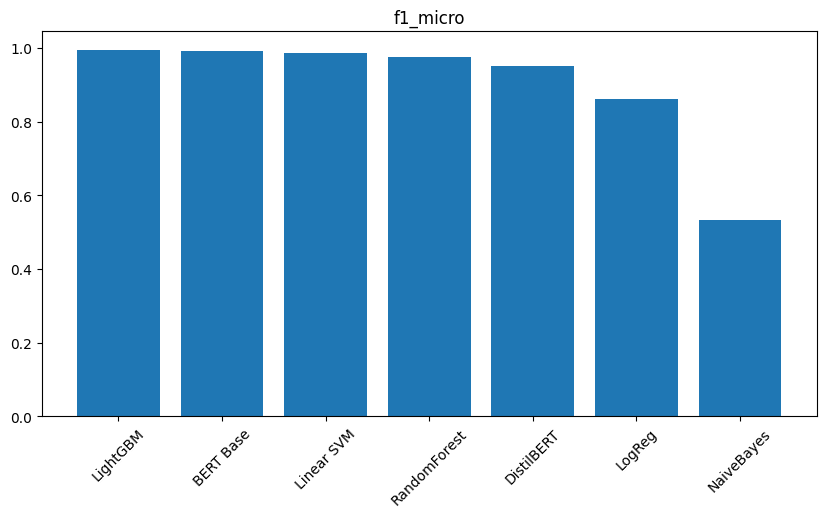

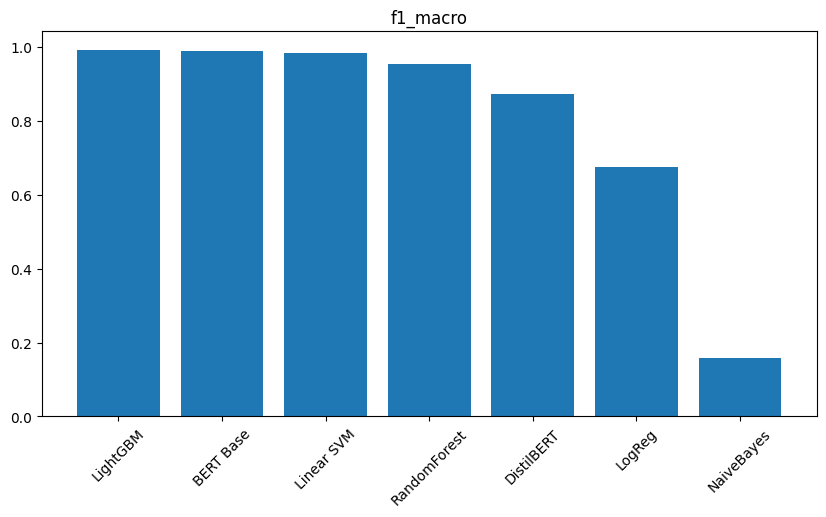

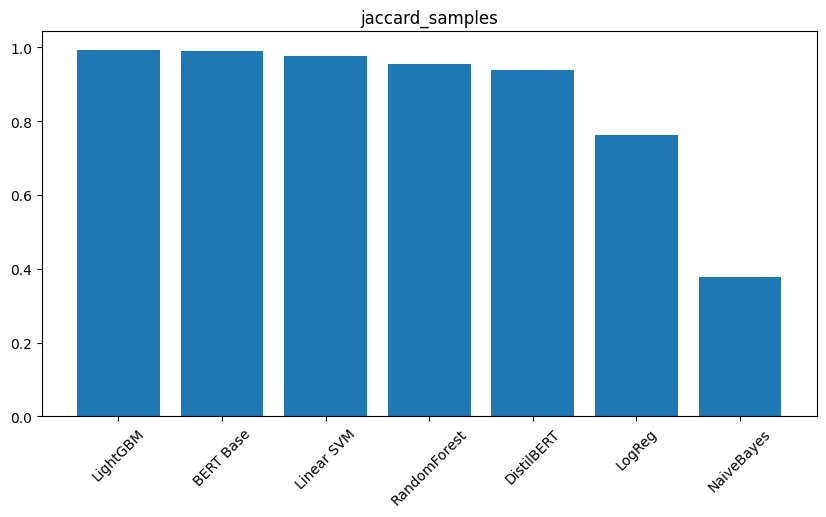

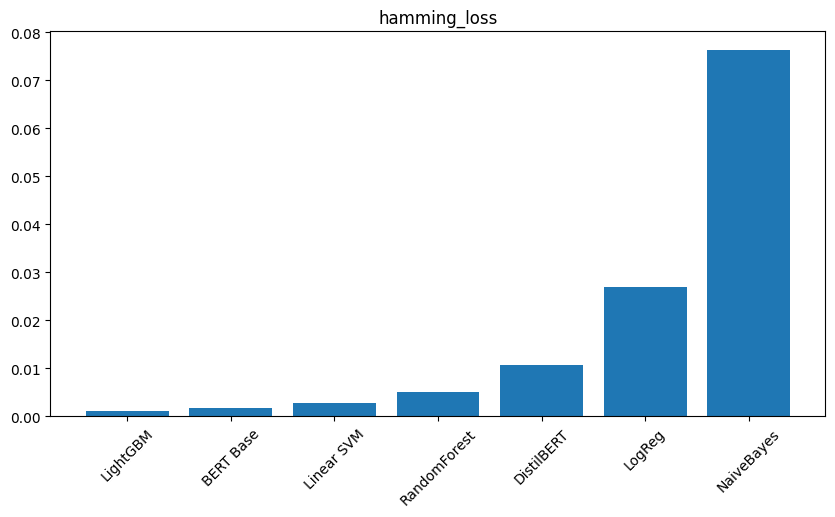

In [7]:
import pandas as pd

def collect_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred)
    }

results_list = []

results_list.append(collect_metrics("NaiveBayes", y_test, pred_nb))
results_list.append(collect_metrics("LogReg", y_test, pred_lr))
results_list.append(collect_metrics("Linear SVM", y_test, pred_svm))
results_list.append(collect_metrics("RandomForest", y_test, pred_rf))
results_list.append(collect_metrics("LightGBM", y_test, pred_lgbm))

import numpy as np
import torch

def transformer_predict(texts, tokenizer, model, threshold=0.5):
    preds = []
    model.eval()
    with torch.no_grad():
        for t in texts:
            enc = tokenizer(
                t,
                truncation=True,
                padding="max_length",
                max_length=256,
                return_tensors="pt"
            ).to(model.device)

            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds.append((probs >= threshold).astype(int))
    return np.array(preds)

pred_distilbert = transformer_predict(
    X_test.tolist(),
    tokenizer_distilbert,
    model_distilbert
)

results_list.append(collect_metrics("DistilBERT", y_test, pred_distilbert))

pred_bert = transformer_predict(
    X_test.tolist(),
    tokenizer_bert,
    model_bert
)

results_list.append(collect_metrics("BERT Base", y_test, pred_bert))

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="f1_micro", ascending=False)
results_df

print("\n=== FINAL MODEL COMPARISON ===")
display(results_df.style.format({
    "f1_micro": "{:.4f}",
    "f1_macro": "{:.4f}",
    "jaccard_samples": "{:.4f}",
    "hamming_loss": "{:.4f}"
}))

import matplotlib.pyplot as plt

metrics = ["f1_micro", "f1_macro", "jaccard_samples", "hamming_loss"]

for m in metrics:
    plt.figure(figsize=(10,5))
    plt.bar(results_df["model"], results_df[m])
    plt.title(m)
    plt.xticks(rotation=45)
    plt.show()
